# Examen: Manejo de técnicas de PLN para entender un corpus de datos

**Ricardo Calvo Perez - A01028889**

In [268]:
import os

Extraemos el corpus de nuestro archivo `.txt`. En nuestro caso, decidimos usar el libro de Alicia en el país de las maravillas. Para esto, usamos os para obtener nuestra variable de entorno, donde está almacenada la ruta completa hacia nuestra carpeta de NLP, y posteriormente la juntamos con la dirección donde se encuentra guardado el libro en el formato correspondiente.

In [269]:
base_path = os.getenv("NAT_LANG_PATH")
corpus = os.path.join(
    base_path,
    'Data',
    'AliceAdventuresInWonderland.txt'
)

En este apartado cargamos el libro (_Alicia en el país de las maravillas_), especificado por la ruta `corpus`.

Se quiso tener un alcance diferente de un simple copiado línea por línea a un preprocesamiento básico diseñado para optimizar futuros análisis de lenguaje natural (NLP).

En nuestro preprocesamiento diseñamos un segmentador de oraciones basado en un recorrido carácter por carácter para construir nuestro `raw_corpus` con oraciones mejor definidas. Primero limpiamos cada línea eliminando caracteres de formato como `*`, `_` y paréntesis con `re.sub`, y luego vamos acumulando caracteres en `current_chars` mientras avanzamos por el texto. Mantenemos un estado booleano `inside_quote` y un conjunto de comillas (`"“”`) para detectar cuándo empieza y termina una cita. Cuando encontramos una comilla de apertura fuera de cita, “cerramos” cualquier oración que se estuviera acumulando y comenzamos una nueva. Al encontrar la comilla de cierre, consideramos que termina la cita y, al mismo tiempo, la oración completa, por lo que agregamos ese fragmento directamente a `raw_corpus`. Esto nos permite separar las citas como unidades propias, en lugar de mezclarlas con la narración circundante.

De una forma similar tratamos los signos `?` y `!` como delimitadores de oración cuando estamos fuera de comillas, y manejamos el punto `.` solo como final de oración si va seguido de un espacio, lo que ayuda a no cortar por abreviaturas. Cada vez que se detecta un final de oración, se construye la cadena a partir de `current_chars`, se limpia y se añade a `raw_corpus`. Al final, si queda texto en el buffer, también se incorpora como última oración. El resultado es un corpus donde las oraciones normales, las interrogativas, las exclamativas y las citas directas están mejor separadas y listas para los análisis posteriores (preguntas, citas, puntuación, etc.). Finalmente, guardamos este corpus procesado en `ProcessedCorpus.txt` para poder tener una representación más visual y revisar fácilmente cómo quedó la segmentación.



In [270]:
import re

In [ ]:
raw_corpus = []

current_chars = []
inside_quote = False
quote_chars = '"“”'
end_punct_strict = '?!'

with open(corpus, 'r', encoding='utf-8') as f:
    for line in f:
        line = re.sub(r'[*_()]', '', line.rstrip('\n'))
        text = line + " "

        for i, char in enumerate(text):

            # Opening quote starts a new sentence
            if char in quote_chars and not inside_quote:
                sentence = ''.join(current_chars).strip()
                if sentence:
                    raw_corpus.append(sentence)
                current_chars = []  # start new sentence
                inside_quote = True
                current_chars.append(char)
                continue

            # Closing quote ends the quote AND ends the sentence
            if char in quote_chars and inside_quote:
                inside_quote = False
                current_chars.append(char)
                sentence = ''.join(current_chars).strip()
                if sentence:
                    raw_corpus.append(sentence)
                current_chars = []
                continue

            # ? or ! end sentence outside quotes
            if char in end_punct_strict and not inside_quote:
                current_chars.append(char)
                sentence = ''.join(current_chars).strip()
                if sentence:
                    raw_corpus.append(sentence)
                current_chars = []
                continue

            #  ". " end sentence outside quotes
            if char == '.' and not inside_quote:
                next_char = text[i+1] if i+1 < len(text) else ""
                if next_char == " ":
                    current_chars.append(char)
                    sentence = ''.join(current_chars).strip()
                    if sentence:
                        raw_corpus.append(sentence)
                    current_chars = []
                    continue
                else:
                    current_chars.append(char)
                    continue

            current_chars.append(char)

remaining = ''.join(current_chars).strip()
if remaining:
    raw_corpus.append(remaining)

print("\nFirst sentences:")
for s in raw_corpus[:5]:
    print("-", s)

print("\nLast 5 sentences:")
for s in raw_corpus[-5:]:
    print("-", s)

output_path = os.path.join(base_path, 'Data', 'ProcessedCorpus.txt')
with open(output_path, 'w', encoding='utf-8') as f:
    for line in raw_corpus:
        f.write(line + '\n')

print(f'\nProcessed corpus saved to: {output_path}')



First sentences:
- The Project Gutenberg eBook of Alice's Adventures in Wonderland  This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever.
- You may copy it, give it away or re-use it under the terms of the Project Gutenberg License included with this ebook or online at www.gutenberg.org.
- If you are not located in the United States, you will have to check the laws of the country where you are located before using this eBook.
- Title: Alice's Adventures in Wonderland  Author: Lewis Carroll  Release date: June 27, 2008 [eBook #11]                 Most recently updated: June 26, 2025  Language: English  Credits: Arthur DiBianca and David Widger    START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND   [Illustration]     Alice’s Adventures in Wonderland  by Lewis Carroll  THE MILLENNIUM FULCRUM EDITION 3.0  Contents   CHAPTER I.
- Down the Rabbit-Hole  CHAPTER II.

Last 5

## 1. Genere una visualización utilizando la ley de Zipf para ver la calidad del corpus a analizar. Justifique la calidad del corpus en base al grafico presentado.

In [272]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import numpy as np

Para construir la gráfica de Zipf utilizamos `CountVectorizer` porque nos permite transformar el corpus directamente en una matriz de frecuencias sin encargarnos manualmente del tokenizado. Con el parámetro `token_pattern=r"(?u)\b\w+\b"` controlamos exactamente qué se considera una palabra, evitando que símbolos o caracteres aislados alteren el conteo y asegurando que la frecuencia refleje el vocabulario real del corpus.

Una vez vectorizado el texto, obtener las frecuencias totales es tan simple como aplicar `X_bow.sum(axis=0).A1`, lo que nos da un arreglo limpio con la aparición total de cada palabra. A partir de ahí, ordenamos dichas frecuencias de mayor a menor mediante `np.sort`, lo cual es indispensable porque la ley de Zipf se basa precisamente en comparar la posición (rango) con la frecuencia. El rango lo generamos con `np.arange`, que nos da una secuencia consecutiva que coincide con la posición ordenada de cada palabra.

Para visualizar la relación, usamos `plt.loglog`, ya que la distribución de Zipf solo se revela correctamente en una escala logarítmica doble. El gráfico en esta escala permite ver si las frecuencias siguen una tendencia de potencia. Finalmente, agregamos la cuadrícula con `plt.grid` para facilitar la lectura de la caída y la alineación del comportamiento del vocabulario.

Cada una de estas funciones se eligió porque simplifica pasos que de otro modo serían manuales y propensos a errores, permitiendo pasar del corpus a la representación visual de forma directa, consistente y sin perder fidelidad en el proceso.


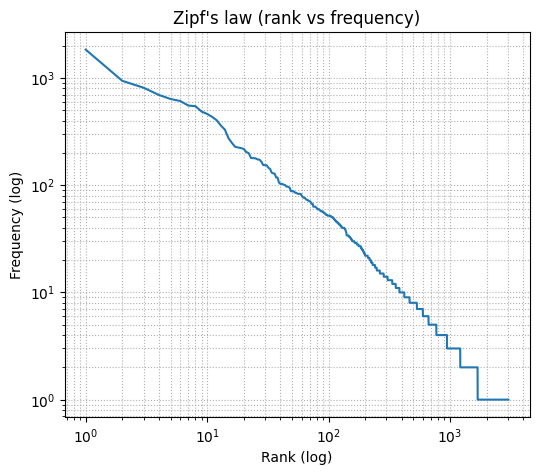

In [ ]:
cv = CountVectorizer(binary=False, token_pattern=r"(?u)\b\w+\b")
X_bow = cv.fit_transform(raw_corpus)
freq = X_bow.sum(axis=0).A1

sorted_freq = np.sort(freq)[::-1]
ranks = np.arange(1, len(sorted_freq)+1)

plt.figure(figsize=(6,5))
plt.loglog(ranks, sorted_freq)
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.title("Zipf's law (rank vs frequency)")
plt.grid(True, which="both", linestyle=":")
plt.show()


## 2. Contar el número total de palabras en el corpus.


Para obtener el número total de palabras en el corpus aprovechamos directamente el arreglo de frecuencias que ya habíamos calculado en el paso anterior. En lugar de volver a procesar el texto o recorrer manualmente los documentos, utilizamos `freq.sum()`, que acumula todas las apariciones individuales de cada palabra en el vocabulario. Esta operación es precisa y eficiente porque `freq` contiene exactamente la frecuencia total de cada término del corpus, resultado del proceso previo de vectorización.

Usamos `sum()` en el arreglo ya que nos entrega en un solo paso la cantidad total de palabras presentes en el corpus completo, sin duplicar trabajo ni volver a tokenizar. 


In [274]:
total_words = freq.sum()
print(f"Total number of words in the corpus: {total_words}")

Total number of words in the corpus: 30575


## 3. Contar la cantidad de palabras únicas en el texto.

Para obtener la cantidad de palabras únicas aprovechamos nuevamente la estructura generada por la vectorización. La matriz de bolsa de palabras construida anteriormente crea una columna por cada término distinto detectado en el corpus, por lo que el arreglo `freq`  que contiene la frecuencia total de cada palabra mantiene una posición por cada una de esas entradas únicas.

En lugar de recalcular vocabularios o volver a tokenizar el texto, usamos `freq.shape[0]`, que nos da directamente el número de elementos del arreglo, es decir, la cantidad total de palabras únicas presentes en el corpus. Esta forma de obtener el resultado es inmediata, coherente con el procesamiento ya realizado y evita repetir trabajo de análisis léxico. 


In [275]:
print(f"Total number of unique words in the corpus: {freq.shape[0]}")

Total number of unique words in the corpus: 3030


## 4. Contar el número de palabras que comienzan con letras mayúsculas.

Para contar las palabras que comienzan con mayúscula, primero extraímos todas las palabras del corpus mediante `re.findall`, lo que nos permitió trabajar con una lista limpia sin signos de puntuación ni separadores erróneos. Luego, dentro del bucle principal, verificamos si cada palabra es alfabética con `isalpha()` y examinamos su primer carácter usando `isupper()`. Esto nos permite identificar de forma precisa solo aquellas palabras que realmente inician con una letra mayúscula y evitar falsos positivos derivados de números o símbolos. El contador se incrementa únicamente cuando la condición se cumple, garantizando un cálculo exacto.

In [ ]:
all_words = []

for sentence in raw_corpus:
    # Extract all sequences of alphanumeric characters interpreted as words
    words_list = re.findall(r'\b\w+\b', sentence)

    # Add the extracted words to the global list
    all_words.extend(words_list)


total_uppercase_words = 0
total_lowercase_words = 0

for palabra in all_words:
    # Process only alphabetic words
    if palabra.isalpha():

        # Count how many words start with an uppercase letter
        # palabra[0] gives the first character
        if palabra[0].isupper():
            total_uppercase_words += 1

        # Count how many words start with a lowercase letter
        elif palabra[0].islower():
            total_lowercase_words += 1


# Display the number of words starting with uppercase letters
print(f"Total number of words that start with uppercase in the corpus: {total_uppercase_words}")


Total number of words that start with uppercase in the corpus: 4034


## 5. Contar el número de palabras que comienzan con letras minúsculas.

Para las palabras que comienzan con minúscula seguimos el mismo recorrido, aprovechando el mismo bucle para no repetir procesamiento innecesario. En este caso, después de descartar elementos no alfabéticos, se usa `islower()` para determinar si la palabra inicia con una letra minúscula. De esta manera se clasifica cada término sin volver a recorrer el corpus ni volver a tokenizarlo, manteniendo consistencia y eficiencia en el análisis.

In [277]:
print(f"Total number of words that starts in lowercase in the corpus: {total_lowercase_words}")

Total number of words that starts in lowercase in the corpus: 26438


## 6. Contar la frecuencia de las palabras cerradas (stopwords) en el corpus.

Para contar las stopwords del corpus utilizamos el conjunto de palabras vacías proporcionado por `nltk`, lo que nos asegura trabajar con una lista estándar y ampliamente usada en tareas de NLP. Primero cargamos el recurso con `nltk.download('stopwords')` y luego extraímos todas las palabras de cada oración usando `re.findall`, lo cual nos da un tokenizado básico pero suficiente para este tipo de análisis. A partir de esa lista filtramos únicamente aquellas palabras que, una vez convertidas a minúsculas, aparecen dentro de `stopwords.words('english')`. Este filtrado directo nos permite evitar confusiones entre versiones mayúsculas/minúsculas y detectar correctamente todas las apariciones reales de términos funcionales.

El resultado se acumula en `corpus_stopwords`, donde cada ocurrencia se registra explícitamente. Esto nos permite obtener tanto el total de stopwords presentes en el corpus como la cantidad de stopwords únicas simplemente aplicando `len()` y `len(set())`. Con este enfoque se mantiene un conteo preciso sin necesidad de estructuras adicionales y se reaprovecha el preprocesamiento previo, evitando volver a recorrer o limpiar el corpus de forma innecesaria.


In [278]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\calvo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [279]:
corpus_stopwords = []

for sentence in raw_corpus:
    # Extract all sequences of alphanumeric characters interpreted as words
    words_list = re.findall(r'\b\w+\b', sentence)

    # Filter and keep only the stopwords from the extracted words
    stopword_list = [word.lower() for word in words_list if word.lower() in stopwords.words('english')]

    # Add the filtered stopwords to the global list
    corpus_stopwords.extend(stopword_list)

print(f"Total number of stopwords in the corpus: {len(corpus_stopwords)}")
print(f"Unique stopwords in the corpus: {len(set(corpus_stopwords))}")


Total number of stopwords in the corpus: 16464
Unique stopwords in the corpus: 146


## 7. Identificar y contar las palabras más comunes en el texto

Para identificar las palabras más comunes del corpus aprovechamos directamente la matriz de frecuencias creada previamente. El vector `freq` contiene la cantidad total de apariciones de cada término, por lo que basta con ordenar estos valores para ubicar los más altos. Usamos `np.argsort(freq)` para obtener los índices ordenados por frecuencia y seleccionamos los últimos `N` elementos —los de mayor valor— invirtiendo luego el orden para mostrar los términos más frecuentes primero. Esto evita cualquier cálculo manual y garantiza que el ranking sea exacto y consistente con el procesamiento previo.

Con `cv.get_feature_names_out()` obtenemos el vocabulario en el mismo orden en que fue generado por la vectorización, lo que permite mapear fácilmente los índices seleccionados a las palabras correspondientes. Al extraer `top_terms` y `top_freqs` podemos imprimir las palabras más comunes junto con su frecuencia real. Este procedimiento es directo, fiable y aprovecha completamente la estructura ya construida por el modelo de bolsa de palabras.


In [280]:
vocab = cv.get_feature_names_out()
N = 6
top_idx = np.argsort(freq)[-N:][::-1]
top_terms = vocab[top_idx]
top_freqs = freq[top_idx]

print(f"Top {N} most common words in the corpus:")
for term, count in zip(top_terms, top_freqs):
    print(f"{term}: {count}")

Top 6 most common words in the corpus:
the: 1839
and: 941
to: 811
a: 695
of: 637
it: 610


## 8. Identificar y contar la frecuencia de nombres propios en el corpus

Para identificar los nombres propios del corpus utilizamos herramientas de `nltk` que permiten ir más allá del simple análisis por patrones. Primero tokenizamos cada oración con `nltk.word_tokenize`, lo que nos da una separación más precisa que una división manual, ya que esta función respeta puntuación, contracciones y estructuras propias del inglés. Posteriormente aplicamos `nltk.pos_tag`, que asigna una etiqueta gramatical a cada token. Esto nos permite distinguir específicamente los sustantivos propios, ya que `NNP` y `NNPS` corresponden a nombres propios en singular y plural. Con esas etiquetas podemos filtrar únicamente los tokens que representan entidades como personajes, lugares o nombres importantes dentro del texto.

Después del filtrado gramatical se realiza una limpieza ligera para eliminar puntuación adherida al inicio o al final del token, garantizando que el nombre capturado sea exacto. También evitamos incluir símbolos o palabras vacías verificando que el resultado contenga letras. Todos los nombres propios válidos se agregan a la lista `proper_names` preservando su capitalización original. Finalmente, con `Counter` obtenemos las frecuencias de aparición de cada nombre propio, lo que permite identificar cuáles son los personajes y entidades más relevantes según su presencia en el corpus.


In [281]:
from collections import Counter
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\calvo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
proper_names = []

for sentence in raw_corpus:
    # Tokenize the sentence into individual tokens
    tokens = nltk.word_tokenize(sentence, language='english')

    # Tag each token with its part of speech
    tagged_words = nltk.pos_tag(tokens)

    for word, tag in tagged_words:
        # Keep only proper nouns (singular or plural)
        if tag in ('NNP', 'NNPS'):

            # Remove punctuation
            cleaned = re.sub(r'^[^A-Za-z]+|[^A-Za-z]+$', '', word)

            # Skip empty results after cleaning
            if not cleaned:
                continue

            # Skip tokens that do not contain letters (avoids symbols)
            if not any(ch.isalpha() for ch in cleaned):
                continue

            # Keep original capitalization for output
            proper_names.append(cleaned)

# Count frequencies of all collected proper nouns
name_counts = Counter(proper_names)


print("\nMost common proper nouns and their frequencies:")
for name, freq in name_counts.most_common(N):
    print(f"'{name}': {freq} occurrences")

print(f"\nTotal unique proper nouns found: {len(name_counts)}")
print(f"Total proper noun occurrences: {sum(name_counts.values())}")



Most common proper nouns and their frequencies:
'Alice': 387 occurrences
'Gutenberg': 84 occurrences
'Project': 80 occurrences
'Queen': 72 occurrences
'King': 61 occurrences
'Turtle': 59 occurrences

Total unique proper nouns found: 426
Total proper noun occurrences: 2100


## 9. Contar el número total de oraciones en el corpus

Para obtener el número total de oraciones no fue necesario realizar un procesamiento adicional, ya que desde el inicio construimos `raw_corpus` de manera que cada elemento representara una oración completa. Este diseño previo permite que la operación sea directa: basta con usar `len(raw_corpus)` para contar cuántas oraciones contiene el corpus. Esta estrategia evita volver a dividir el texto o aplicar tokenización adicional, aprovechando directamente la estructura ya generada durante el preprocesamiento.


In [283]:
print(f"Total number of sentences in the corpus: {len(raw_corpus)}")

Total number of sentences in the corpus: 2454


## 10. Calcular la longitud promedio de las oraciones.

Para calcular la longitud promedio de las oraciones utilizamos directamente la estructura ya organizada en `raw_corpus`, donde cada elemento es una oración completa. Para obtener la longitud en palabras aplicamos `re.findall(r'\b\w+\b', s)` sobre cada oración, lo que nos permite contar únicamente secuencias alfanuméricas interpretadas como palabras, evitando que la puntuación distorsione el resultado. Con esa lista de conteos calculamos el promedio usando `np.mean`, lo que entrega una medida clara del tamaño típico de las oraciones en términos de vocabulario.

De manera complementaria, también medimos la longitud en caracteres tomando simplemente `len(s)` por oración, ya que en este caso no se requiere filtrado: cada oración ya está limpia y delimitada. Computar el promedio con `np.mean` nos da una segunda perspectiva sobre la extensión de las oraciones, útil para entender la complejidad del estilo del texto. Ambas métricas se obtienen sin reprocesar el corpus y reutilizando el preprocesamiento ya realizado.


In [284]:
# Calculate average sentence length in words and characters
sentence_word_counts = [len(re.findall(r'\b\w+\b', s)) for s in raw_corpus]
avg_words_per_sentence = np.mean(sentence_word_counts)

sentence_char_counts = [len(s) for s in raw_corpus]
avg_chars_per_sentence = np.mean(sentence_char_counts)

print(f"Average sentence length: {avg_words_per_sentence:.2f} words")
print(f"Average sentence length: {avg_chars_per_sentence:.2f} characters")

Average sentence length: 12.46 words
Average sentence length: 65.08 characters


## 11. Contar cuántas veces aparecen cada uno de los signos de puntuación.

Para contar la frecuencia de los signos de puntuación definimos primero un patrón con las marcas que nos interesaba rastrear. Usamos `re.findall` porque permite detectar cada aparición individual dentro de cada oración, sin importar su posición ni contexto. Al recorrer `raw_corpus` extraemos todas las coincidencias y las acumulamos en una lista global, lo que nos da un registro exhaustivo de cada signo encontrado en el texto.

Una vez recopiladas todas las marcas utilizamos `Counter`, que facilita agruparlas y obtener la frecuencia de cada tipo de signo sin necesidad de estructuras adicionales. Esto nos permite generar un recuento detallado por símbolo y también calcular el total acumulado de signos de puntuación presentes en el corpus. El procedimiento es directo, preciso y reutiliza la estructura del corpus ya preprocesado sin necesidad de tokenizaciones extra.


In [285]:
punctuation_pattern = r'[.,;:“”\'?!()\[\]\{\}]'
all_punctuation_marks = []

for sentence in raw_corpus:
    # find all returns a list with EACH punctuation mark found
    found_marks = re.findall(punctuation_pattern, sentence)
    all_punctuation_marks.extend(found_marks)

# Counter groups and counts all punctuation marks automatically
final_count = Counter(all_punctuation_marks)

print("Detailed punctuation count:")
print("-" * 30)

# Iterate over each unique punctuation mark and its frequency
for mark, freq in final_count.items():
    print(f"Mark '{mark}': {freq} occurrences")

print("-" * 30)
print(f"Total punctuation marks found: {sum(final_count.values())}")


Detailed punctuation count:
------------------------------
Mark ''': 4 occurrences
Mark '.': 1221 occurrences
Mark ',': 2571 occurrences
Mark ':': 246 occurrences
Mark '[': 4 occurrences
Mark ']': 4 occurrences
Mark '?': 204 occurrences
Mark '“': 1128 occurrences
Mark '”': 1125 occurrences
Mark ';': 193 occurrences
Mark '!': 452 occurrences
------------------------------
Total punctuation marks found: 7152


## 12. Encontrar las palabras más largas en el texto.


Para identificar las palabras más largas del corpus partimos de la lista `all_words`, filtrando únicamente aquellas que son completamente alfabéticas mediante `isalpha()`. Esto elimina números, símbolos y cualquier token que pudiera distorsionar la medición. Luego convertimos la lista en un conjunto para eliminar duplicados, ya que lo relevante en este punto es analizar la variedad léxica y no la frecuencia de aparición.

Con el conjunto limpio de palabras únicas aplicamos una ordenación personalizada usando `sorted` y una función `key` que prioriza primero la longitud negativa —lo que coloca las palabras más largas al inicio— y, en caso de empate, ordena alfabéticamente para mantener consistencia. Al seleccionar las primeras `N` palabras obtenemos un conjunto claro y organizado de los términos más extensos del corpus, junto con su longitud, sin necesidad de recurrir a procesamiento adicional.


In [286]:
# Keep only alphabetic words
alphabetic_words = [w for w in all_words if w.isalpha()]

# Remove duplicates
unique_words = set(alphabetic_words)

# Sort words by length (longest first); tie-breaker: alphabetical order
sorted_by_length = sorted(unique_words, key=lambda w: (-len(w), w.lower()))

# Choose how many longest words you want to see

print(f"Top {N} longest words in the corpus:\n")
for word in sorted_by_length[:N]:
    print(f"{word} — {len(word)} letters")


Top 6 longest words in the corpus:

unenforceability — 16 letters
MERCHANTABILITY — 15 letters
representations — 15 letters
affectionately — 14 letters
contemptuously — 14 letters
disappointment — 14 letters


## 13. Contar el número de oraciones interrogativas.


Para contar las oraciones interrogativas analizamos cada elemento de `raw_corpus` buscando la presencia del signo de interrogación. La estrategia consiste en dividir cada oración usando `split('?')`, lo que permite identificar cuántas preguntas podrían estar contenidas en una misma línea. Cada aparición del signo indica una potencial pregunta, así que procesamos todas las partes excepto la última, que corresponde al texto posterior al último `?`.

Para obtener únicamente la parte interrogativa aislamos el fragmento inmediatamente anterior al signo. Utilizamos `re.split` para recortar cualquier narrativa o puntuación previa y conservar únicamente la cláusula que forma la pregunta. Después reconstruimos la pregunta añadiendo nuevamente el `?` y filtramos resultados vacíos o irrelevantes. Cada pregunta válida se agrega a la lista `questions`, lo que permite contabilizar de forma precisa todas las interrogativas presentes en el corpus, incluso cuando aparecen varias dentro de una misma oración original.


In [ ]:
questions = []

for sentence in raw_corpus:
    # Split the sentence wherever a '?' occurs
    parts = sentence.split('?')

    # Each '?' indicates one question, so iterate over all but the last part
    for i in range(len(parts) - 1):
        text_before_question = parts[i]

        # Keep only the clause immediately before the '?'
        fragment = re.split(r'[.!?“”"]', text_before_question)[-1]

        # Reconstruct the question by adding the '?'
        question_text = fragment.strip() + '?'

        # Avoid empty or extremely short fragments
        if len(question_text.strip()) > 1:
            questions.append(question_text)

print(f"Total number of questions found in the corpus: {len(questions)}")


Total number of questions found in the corpus: 204


## 14. Identificar y extraer entidades como nombres de personas, lugares y organizaciones.


Para extraer entidades nombradas utilizamos el módulo de NER de `nltk`, que requiere varios modelos previamente descargados: tokenizador, etiquetador gramatical y el clasificador de entidades. Estos recursos permiten que el análisis sea lingüísticamente informado y no dependa de simples reglas o patrones manuales. Para cada oración, primero tokenizamos con `word_tokenize`, asegurando una segmentación precisa del texto. Luego aplicamos `pos_tag` para obtener las categorías gramaticales que sirven como base para el reconocimiento de entidades. Con estos datos alimentamos `ne_chunk`, que genera un árbol donde aparecen agrupadas entidades etiquetadas como PERSON, GPE o ORGANIZATION.

Después de obtener el árbol, recorremos sus nodos y seleccionamos únicamente aquellos subárboles que representan entidades reales. Para cada entidad unimos los tokens que la componen y los almacenamos en `collected_entities` bajo su categoría correspondiente. Al final, convertimos cada lista en un `Counter` para obtener sus frecuencias, lo que permite identificar las entidades más recurrentes del texto. Este flujo asegura una extracción precisa, estructurada y respaldada por modelos entrenados específicamente para este tipo de tareas.


In [288]:
from collections import defaultdict

nltk.download('punkt', quiet=True)

nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True)
nltk.download('words', quiet=True)

True

In [ ]:
collected_entities = defaultdict(list)

for sentence in raw_corpus:
    # Tokenize the sentence into words
    tokens = nltk.word_tokenize(sentence, language='english')

    # POS tagging
    tagged_tokens = nltk.pos_tag(tokens)

    # Named Entity Recognition
    ne_tree = nltk.ne_chunk(tagged_tokens, binary=False)

    # Traverse the tree and collect entities of interest
    for subtree in ne_tree:
        if isinstance(subtree, nltk.Tree):
            label = subtree.label()

            if label in ('PERSON', 'GPE', 'ORGANIZATION'):
                entity_name = " ".join(token for token, pos in subtree.leaves())
                collected_entities[label].append(entity_name)

entities = {
    label: Counter(names) for label, names in collected_entities.items()
}


print(f"\n{N} Most common PERSON entities:")
for name, freq in entities.get('PERSON', Counter()).most_common(N):
    print(f"'{name}': {freq} occurrences")

print(f"\n{N} Most common GPE (locations) entities:")
for name, freq in entities.get('GPE', Counter()).most_common(N):
    print(f"'{name}': {freq} occurrences")

print(f"\n{N} Most common ORGANIZATION entities:")
for name, freq in entities.get('ORGANIZATION', Counter()).most_common(N):
    print(f"'{name}': {freq} occurrences")



6 Most common PERSON entities:
'Alice': 159 occurrences
'Gryphon': 17 occurrences
'Bill': 14 occurrences
'Project': 14 occurrences
'Hatter': 13 occurrences
'Hare': 10 occurrences

6 Most common GPE (locations) entities:
'Alice': 36 occurrences
'Gryphon': 16 occurrences
'United States': 15 occurrences
'Pigeon': 6 occurrences
'Wonderland': 5 occurrences
'English': 5 occurrences

6 Most common ORGANIZATION entities:
'Mock Turtle': 54 occurrences
'Duchess': 42 occurrences
'Dormouse': 37 occurrences
'Caterpillar': 26 occurrences
'Mouse': 26 occurrences
'Gryphon': 22 occurrences


## 15. Encontrar y extraer todas las citas directas (entre comillas) en el corpus.


Para extraer las citas directas definimos un patrón regular que detecta texto encerrado entre comillas rectas o tipográficas. El uso de `re.finditer` permite capturar cada coincidencia de forma completa, incluyendo las comillas, en lugar de trabajar solo con el contenido interno. Esta elección facilita conservar la cita tal como aparece en el texto original y evita perder información contextual importante, como el tipo de comillas o posibles espacios asociados.

Al recorrer cada oración del corpus, el patrón identifica todas las secuencias entre comillas, incluso cuando contienen varios caracteres o saltos internos gracias al uso del modificador `DOTALL`. Cada fragmento detectado se almacena en la lista `quotes`, después de una limpieza ligera para eliminar posibles espacios externos. Con esta colección completa es posible mostrar ejemplos y contabilizar con precisión cuántas citas directas están presentes en el corpus, sin depender de su longitud ni de su posición dentro de la oración.


In [ ]:
quotes = []
quote_pattern = r'[“"](.*?)[”"]'

for sentence in raw_corpus:
    # Access the full match
    for match in re.finditer(quote_pattern, sentence, flags=re.DOTALL):
        full_quote = match.group(0).strip()
        if full_quote:
            quotes.append(full_quote)

print("\nExample extracted quotes WITH quotes:")
for q in quotes[:N]:
    print("-", q)

print(f"\nTotal direct quotes found: {len(quotes)}")



Example extracted quotes WITH quotes:
- “and what is the use of a book,”
- “without pictures or conversations?”
- “Oh dear! Oh dear! I shall be late!”
- “ORANGE MARMALADE”
- “Well!”
- “after such a fall as this, I shall think nothing of tumbling down stairs! How brave they’ll all think me at home! Why, I wouldn’t say anything about it, even if I fell off the top of the house!”

Total direct quotes found: 1040


## 16. Detectar y extraer preguntas en el texto.


Para mostrar y analizar las preguntas extraídas no fue necesario volver a recorrer el corpus ni aplicar reglas adicionales, ya que previamente habíamos construido la lista `questions` con cada interrogativa detectada y reconstruida desde el texto original. En este punto simplemente reutilizamos ese trabajo y presentamos los fragmentos ya identificados. Usar `questions[:N]` permite visualizar solo una muestra controlada, manteniendo el resultado claro y manejable. Esta estrategia aprovecha directamente la extracción previa sin repetir procesamiento y garantiza que las preguntas mostradas sean exactamente las mismas que fueron identificadas durante el análisis interrogativo.


In [291]:
print("\nExtracted question fragments:")
for q in questions[:N]:
    print("-", q)


Extracted question fragments:
- Who Stole the Tarts?
- without pictures or conversations?
- Would the fall never come to an end?
- I wonder how many miles I’ve fallen by this time?
- —yes, that’s about the right distance—but then I wonder what Latitude or Longitude I’ve got to?
- Please, Ma’am, is this New Zealand or Australia?


## 17. Identificar palabras que tienen más de un significado.


Para identificar palabras con múltiples significados recurrimos a **WordNet**, un léxico digital ampliamente utilizado en lingüística computacional. Aunque esta herramienta no formó parte directa del curso, es uno de los recursos estándar en análisis semántico y está integrado dentro de `nltk`, lo que permite acceder a definiciones, sinónimos y sentidos distintos de una misma palabra. Descargamos tanto `wordnet` como `omw-1.4`, que es un conjunto multilingüe que complementa la base principal y asegura que los synsets estén completos y actualizados. Esto garantiza que la información semántica utilizada provenga de una fuente confiable y estructurada.

Para el análisis, primero limpiamos todas las palabras alfabéticas y las unificamos en minúsculas, lo que evita duplicados y reduce variaciones irrelevantes. Luego, para cada palabra consultamos sus synsets mediante `wn.synsets(word)`. Cada synset representa un posible significado o uso de la palabra dentro de WordNet. Cuando una palabra tiene más de un synset, se considera polisémica. Al detectar estos casos, los guardamos en un diccionario junto con los sentidos asociados. Finalmente imprimimos ejemplos mostrando cuántos significados tiene cada palabra y las definiciones de WordNet. Este procedimiento permite evaluar la riqueza semántica del vocabulario del corpus utilizando una herramienta diseñada específicamente para representar la estructura del significado en inglés.


In [292]:
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\calvo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\calvo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
clean_words = {w.lower() for w in all_words if w.isalpha()}

polysemous = {}

# Identify words that have more than one sense in WordNet
for word in clean_words:
    synsets = wn.synsets(word)
    if len(synsets) > 1:
        polysemous[word] = synsets

print(f"Total polysemous words found: {len(polysemous)}\n")

for word, synsets in list(polysemous.items())[:N]:
    print(f"Word: {word} — {len(synsets)} meanings")
    for syn in synsets:
        print("   •", syn.definition())


Total polysemous words found: 2535

Word: answer — 15 meanings
   • a statement (either spoken or written) that is made to reply to a question or request or criticism or accusation
   • a statement that solves a problem or explains how to solve the problem
   • the speech act of replying to a question
   • the principal pleading by the defendant in response to plaintiff's complaint; in criminal law it consists of the defendant's plea of `guilty' or `not guilty' (or nolo contendere); in civil law it must contain denials of all allegations in the plaintiff's complaint that the defendant hopes to controvert and it can contain affirmative defenses or counterclaims
   • a nonverbal reaction
   • react verbally
   • respond to a signal
   • give the correct answer or solution to
   • understand the meaning of
   • give a defence or refutation of (a charge) or in (an argument)
   • be liable or accountable
   • be sufficient; be adequate, either in quality or quantity
   • match or correspond

## 18. Encontrar los bigramas, trigramas y cuatrigramas más relevantes en el texto.


Para obtener los bigramas, trigramas y cuatrigramas más relevantes del corpus trabajamos directamente con `all_words`, filtrando únicamente las palabras alfabéticas y normalizándolas a minúsculas para evitar duplicados causados por diferencias de capitalización. Esta lista limpia sirve como base para construir n-gramas continuos que representen secuencias reales del texto.

Utilizamos la función `ngrams` de `nltk`, que genera automáticamente pares, tríos o grupos de cuatro palabras consecutivas según el tamaño indicado. Esta herramienta evita implementar manualmente ventanas deslizantes y garantiza que las secuencias se formen respetando el orden real en el corpus. Una vez generados los n-gramas, empleamos `Counter` para contabilizar sus apariciones, lo que permite identificar cuáles son las combinaciones más frecuentes. Finalmente, mostramos los n-gramas más comunes ordenados por frecuencia, proporcionando una visión clara sobre patrones recurrentes, asociaciones léxicas y posibles unidades semánticas del texto.


In [294]:
from nltk.util import ngrams

In [295]:
tokens = [w.lower() for w in all_words if w.isalpha()]

bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))
fourgrams = list(ngrams(tokens, 4))

bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)
fourgram_freq = Counter(fourgrams)

print(f"\nTop {N} most frequent bigrams:")
for ng, freq in bigram_freq.most_common(N):
    print(" ".join(ng), "—", freq)

print(f"\nTop {N} most frequent trigrams:")
for ng, freq in trigram_freq.most_common(N):
    print(" ".join(ng), "—", freq)

print(f"\nTop {N} most frequent four-grams:")
for ng, freq in fourgram_freq.most_common(N):
    print(" ".join(ng), "—", freq)



Top 6 most frequent bigrams:
said the — 210
of the — 167
said alice — 116
in a — 102
in the — 99
project gutenberg — 88

Top 6 most frequent trigrams:
the mock turtle — 54
the project gutenberg — 33
i don t — 31
the march hare — 30
said the king — 29
the white rabbit — 21

Top 6 most frequent four-grams:
said the mock turtle — 19
she said to herself — 16
the project gutenberg literary — 13
project gutenberg literary archive — 13
gutenberg literary archive foundation — 13
project gutenberg electronic works — 12


## 19. Identificar cuáles son los temas/tópicos más recurrentes en el texto.


Para identificar los tópicos más recurrentes en el texto utilizamos un modelo de temas LDA (`LdaModel`) de la biblioteca `gensim`, que está diseñado justamente para extraer patrones temáticos a partir de grandes colecciones de documentos. Primero construimos `processed_sentences` a partir de `raw_corpus`: tokenizamos cada oración con `nltk.word_tokenize`, nos quedamos solo con tokens alfabéticos, los pasamos a minúsculas para normalizar y después filtramos stopwords y palabras muy cortas (longitud ≤ 2) que no aportan contenido semántico útil. Este filtrado previo es clave para que el modelo se centre en términos realmente informativos y no en palabras funcionales o ruido.

Con las oraciones ya limpias construimos un `Dictionary` de `gensim`, que asigna un identificador numérico a cada palabra distinta y sirve de puente entre el texto y las representaciones numéricas. A partir de ahí generamos `bow_corpus`, una versión en bolsa de palabras donde cada documento se representa como pares `(id_palabra, frecuencia)`. Este formato es el que consume directamente `LdaModel`, al que le indicamos cuántos tópicos queremos (`num_topics`), cuántas pasadas hacer sobre el corpus (`passes`) y un `random_state` fijo para reproducibilidad. El modelo resultante nos devuelve, para cada tópico, las palabras más representativas junto con su peso, lo que permite interpretar y nombrar los temas dominantes del libro a partir de coocurrencias y patrones estadísticos en lugar de inspección manual.


In [296]:
from gensim import corpora, models

In [ ]:
processed_sentences = []
stop_words = set(stopwords.words('english'))

for sentence in raw_corpus:
    # Tokenize the sentence and keep only alphabetic tokens
    words = [w.lower() for w in nltk.word_tokenize(sentence) if w.isalpha()]

    # Remove stopwords and remove very short words that are not useful
    words = [w for w in words if w not in stop_words and len(w) > 2]

    processed_sentences.append(words)

dictionary = corpora.Dictionary(processed_sentences)
bow_corpus = [dictionary.doc2bow(text) for text in processed_sentences]

num_topics = N
lda_model = models.LdaModel(
    bow_corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=10,
    random_state=42
)

print("\nExtracted Topics:")
for idx, topic in lda_model.show_topics(num_topics=num_topics, formatted=False):
    print(f"\nTopic {idx + 1}:")
    for word, weight in topic:
        print(f"  {word} ({weight:.3f})")


Extracted Topics:

Topic 1:
  alice (0.022)
  queen (0.019)
  one (0.016)
  began (0.014)
  would (0.014)
  could (0.012)
  dormouse (0.011)
  got (0.011)
  court (0.011)
  put (0.010)

Topic 2:
  said (0.114)
  alice (0.050)
  king (0.034)
  project (0.031)
  work (0.027)
  terms (0.019)
  hatter (0.017)
  license (0.015)
  electronic (0.013)
  thought (0.011)

Topic 3:
  little (0.022)
  head (0.016)
  first (0.014)
  alice (0.013)
  thing (0.012)
  one (0.010)
  made (0.008)
  found (0.008)
  time (0.008)
  looking (0.007)

Topic 4:
  works (0.040)
  must (0.023)
  full (0.015)
  work (0.015)
  jury (0.015)
  know (0.013)
  refund (0.011)
  agreement (0.010)
  right (0.010)
  course (0.008)

Topic 5:
  project (0.056)
  gutenberg (0.029)
  foundation (0.021)
  archive (0.014)
  literary (0.014)
  would (0.013)
  information (0.009)
  electronic (0.008)
  see (0.008)
  ebooks (0.008)

Topic 6:
  states (0.021)
  copyright (0.018)
  said (0.018)
  united (0.016)
  turtle (0.015)
  mo

## 20. Construir una representación de tipo Bag of Words y TF-IDF  y comparar cuales son las palabras mas relevantes para ambas sin tomar en cuenta las palabras cerradas.


Para comparar las palabras más relevantes usando Bag of Words y TF-IDF, primero construimos un corpus limpio en `cleaner_corpus`. Tokenizamos cada oración con `nltk.word_tokenize` y luego limpiamos cada token eliminando puntuación con `strip(string.punctuation)`, descartando tokens vacíos, no alfabéticos y cualquier palabra que aparezca en la lista de stopwords en inglés (`stopwords_en`). Además, normalizamos todo a minúsculas. Con esto nos aseguramos de que ni signos de puntuación ni las  palabras  cerradas influyan, de modo que nos quedamos con los terminos que si _"importan"_ en el texto.

Sobre este corpus ya filtrado construimos dos representaciones distintas. Con `CountVectorizer` para la matriz de Bag of Words, sumamos las columnas para obtener la frecuencia global de cada palabra (`bow_counts`) y ordenamos los índices para recuperar las más frecuentes.  Para el caso de TF-IDF, usamos `TfidfVectorizer` configurando el modelo para que utilice tanto TF como IDF. Esto porque en las tareas pasadas  esto nos dio buenos resultados al destacar términos que no solo aparecen, sino que tienen un peso relevante dentro del texto. Por eso forzamos explícitamente el uso conjunto de TF e IDF.




In [298]:
import string

In [ ]:
stopwords_en = set(stopwords.words("english"))

cleaner_corpus = []

for line in raw_corpus:
    tokens = nltk.word_tokenize(line)
    clean_tokens = []

    for t in tokens:
        # Remove punctuation around the token
        t = t.strip(string.punctuation)

        # Skip empty and non alphabetic tokens
        if not t or not t.isalpha():
            continue

        # Skip stopwords
        if t.lower() in stopwords_en:
            continue

        clean_tokens.append(t.lower())

    cleaner_corpus.append(" ".join(clean_tokens))


for line in cleaner_corpus[:N]:
    print(line)


project gutenberg ebook alice adventures wonderland ebook use anyone anywhere united states parts world cost almost restrictions whatsoever
may copy give away terms project gutenberg license included ebook online
located united states check laws country located using ebook
title alice adventures wonderland author lewis carroll release date june ebook recently updated june language english credits arthur dibianca david widger start project gutenberg ebook alice adventures wonderland illustration alice adventures wonderland lewis carroll millennium fulcrum edition contents chapter
chapter ii
pool tears chapter iii


In [ ]:
X_bow_vec = CountVectorizer(binary=False, token_pattern=r"(?u)\b\w+\b")
X_bow = X_bow_vec.fit_transform(cleaner_corpus)
bow_feature_names = np.array(X_bow_vec.get_feature_names_out())

bow_counts = X_bow.sum(axis=0).A1

bow_sorted_idx = np.argsort(bow_counts)[::-1]

print(f"\nTop {N} most frequent words (Bag of Words):")
for idx in bow_sorted_idx[:N]:
    print(f"{bow_feature_names[idx]} — count: {bow_counts[idx]}")



Top 6 most frequent words (Bag of Words):
said — count: 458
alice — count: 402
little — count: 128
one — count: 103
project — count: 88
like — count: 85


In [301]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
tfidf_vec = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    sublinear_tf=True,
    use_idf=True,
)
tfidf = tfidf_vec.fit_transform(cleaner_corpus)

tfidf_feature_names = np.array(tfidf_vec.get_feature_names_out())

tfidf_scores = tfidf.sum(axis=0).A1

tfidf_sorted_idx = np.argsort(tfidf_scores)[::-1]

print(f"\nTop {N} most relevant words (TF-IDF):")
for idx in tfidf_sorted_idx[:N]:
    print(f"{tfidf_feature_names[idx]} — tfidf sum: {tfidf_scores[idx]:.4f}")



Top 6 most relevant words (TF-IDF):
said — tfidf sum: 170.0913
alice — tfidf sum: 121.1401
thought — tfidf sum: 42.5898
king — tfidf sum: 30.7226
know — tfidf sum: 30.5942
hatter — tfidf sum: 30.1710


## 21. Entrenar un modelo de embeddings y analizar qué palabras presentan mayor similitud semántica con el término clave que ustedes consideren del corpus.

Para entrenar el modelo de embeddings primero preparamos un corpus específicamente pensado para Word2Vec. A partir de `raw_corpus` tokenizamos cada línea con `nltk.word_tokenize`, limpiamos la puntuación a las palabras con `strip(string.punctuation)`, descartamos tokens vacíos o no alfabéticos y normalizamos todo a minúsculas de la misma manera en que lo hemos estado haciendo en los últimos puntos. El resultado es `tokenized_for_embeddings_corpus`, una lista de listas donde cada sublista representa una oración como secuencia de palabras limpias. Esto para cumplir con el formato que espera `Word2Vec`.

Después entrenamos un modelo `Word2Vec` de `gensim` configurando parámetros típicos para este tipo de tarea: `vector_size=100` para obtener vectores lo suficientemente expresivos, `window=5` para capturar contexto cercano, `min_count=3` para ignorar palabras extremadamente raras y `sg=1` para usar el modelo skip-gram, que en pruebas hechas para las tareas descubrimos que tiende a capturar mejor relaciones semánticas en corpus. Con el modelo entrenado obtenemos el vocabulario (`key_to_index`) y elegimos una palabra al azar como término clave, con el objetivo de ilustrar cómo el modelo encuentra palabras semánticamente similares usando `most_similar`. 


In [ ]:
tokenized_for_embeddings_corpus = []

for line in raw_corpus:
    tokens = nltk.word_tokenize(line)

    clean_tokens = []
    for t in tokens:
        t = t.strip(string.punctuation)

        if not t or not t.isalpha():
            continue

        clean_tokens.append(t.lower())

    if clean_tokens:
        tokenized_for_embeddings_corpus.append(clean_tokens)

for sent in tokenized_for_embeddings_corpus[:N]:
    print(sent)

['the', 'project', 'gutenberg', 'ebook', 'of', 'alice', 's', 'adventures', 'in', 'wonderland', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever']
['you', 'may', 'copy', 'it', 'give', 'it', 'away', 'or', 'it', 'under', 'the', 'terms', 'of', 'the', 'project', 'gutenberg', 'license', 'included', 'with', 'this', 'ebook', 'or', 'online', 'at']
['if', 'you', 'are', 'not', 'located', 'in', 'the', 'united', 'states', 'you', 'will', 'have', 'to', 'check', 'the', 'laws', 'of', 'the', 'country', 'where', 'you', 'are', 'located', 'before', 'using', 'this', 'ebook']
['title', 'alice', 's', 'adventures', 'in', 'wonderland', 'author', 'lewis', 'carroll', 'release', 'date', 'june', 'ebook', 'most', 'recently', 'updated', 'june', 'language', 'english', 'credits', 'arthur', 'dibianca', 'and', 'david', 'widger', 'star

In [304]:
from gensim.models import Word2Vec
import random

In [ ]:
w2v_model = Word2Vec(
    sentences=tokenized_for_embeddings_corpus,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    epochs=10
)


In [306]:
# Get all words in the vocabulary
vocab_words = list(w2v_model.wv.key_to_index.keys())

# Pick a random word as key term
random_key = random.choice(vocab_words)
print("Random key term:", random_key)

print(f"\nMost similar words to '{random_key}':")
for word, sim in w2v_model.wv.most_similar(random_key, topn=10):
    print(f"  {word} — {sim:.4f}")


Random key term: shoes

Most similar words to 'shoes':
  several — 0.9967
  worse — 0.9958
  play — 0.9958
  em — 0.9954
  consider — 0.9954
  mary — 0.9954
  porpoise — 0.9952
  swim — 0.9952
  verdict — 0.9952
  twelve — 0.9951


## 22. Generar embeddings contextuales (BERT, por ejemplo) para varias oraciones del corpus y analizar cómo cambia el vector de una misma palabra cuando aparece en contextos diferentes.


Para generar embeddings contextuales utilizamos un modelo BERT preentrenado a través de `transformers`. Primero filtramos `raw_corpus` para quedarnos solo con oraciones que contienen la palabra objetivo, qu en este caso va a ser `alice` y después usamos el `AutoTokenizer` para convertir cada oración en tokens compatibles con BERT, respetando los (subtokens). Con la función `get_word_embedding_in_sentence` pasamos cada oración por el modelo (`AutoModel`), obtenemos la última capa oculta (`last_hidden_state`) y localizamos la posición exacta de la palabra objetivo comparando la secuencia de subtokens que BERT genera para “alice”. Cuando la encontramos, promediamos los vectores de todos los subtokens de esa palabra para construir un embedding único por ocurrencia en cada oración.

Una vez que tenemos un embedding por cada aparición de “alice”, los apilamos en una matriz y calculamos la similitud del coseno entre todos ellos. Esto nos permite cuantificar qué tan parecidas son las representaciones de “alice” en distintos contextos, sin tener que “ver” el espacio de alta dimensión. La com


In [307]:
from transformers import AutoTokenizer, AutoModel
import torch


In [ ]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()


def get_word_embedding_in_sentence(sentence, target_word, tokenizer, model, device, max_length=128):
    encoded = tokenizer(
        sentence,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state[0]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    target_tokens = tokenizer.tokenize(target_word.lower())


    indices_spans = []
    for i in range(len(tokens) - len(target_tokens)):
        if tokens[i:i+len(target_tokens)] == target_tokens:
            indices_spans.append(list(range(i, i+len(target_tokens))))

    if not indices_spans:
        return None, tokens

    span = indices_spans[0]

    span_embeddings = last_hidden[span]
    word_embedding = span_embeddings.mean(dim=0)

    return word_embedding.cpu().numpy(), tokens


target_word = "alice"

sentences_with_target = [s for s in raw_corpus if target_word.lower() in s.lower()]

print(f"Total sentences containing '{target_word}': {len(sentences_with_target)}")

num_sentences_to_analyze = 10
sentences_sample = sentences_with_target[:num_sentences_to_analyze]

print("\nSample sentences with the target word:")
for i, s in enumerate(sentences_sample):
    print(f"\nSentence {i}:")
    print(s)


embeddings = []
valid_sentences = []

for s in sentences_sample:
    emb, toks = get_word_embedding_in_sentence(
        sentence=s,
        target_word=target_word,
        tokenizer=tokenizer,
        model=bert_model,
        device=device,
        max_length=128
    )

    if emb is not None:
        embeddings.append(emb)
        valid_sentences.append(s)

embeddings = np.stack(embeddings, axis=0)

print(f"\nCollected embeddings for {embeddings.shape[0]} occurrences of '{target_word}'.")


def cosine_similarity_matrix(X):
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    return np.dot(X_norm, X_norm.T)

similarity_matrix = cosine_similarity_matrix(embeddings)


print("\nCosine similarity of each occurrence vs the first one:\n")

for i, sentence in enumerate(valid_sentences):
    sim_to_first = similarity_matrix[0, i]
    print(f"Occurrence {i} — similarity to occurrence 0: {sim_to_first:.4f}")
    print("  Sentence:", sentence[:200], "...\n")


print("Cosine similarity matrix between all occurrences:\n")
print(similarity_matrix)


Total sentences containing 'alice': 394

Sample sentences with the target word:

Sentence 0:
The Project Gutenberg eBook of Alice's Adventures in Wonderland  This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever.

Sentence 1:
Title: Alice's Adventures in Wonderland  Author: Lewis Carroll  Release date: June 27, 2008 [eBook #11]                 Most recently updated: June 26, 2025  Language: English  Credits: Arthur DiBianca and David Widger    START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND   [Illustration]     Alice’s Adventures in Wonderland  by Lewis Carroll  THE MILLENNIUM FULCRUM EDITION 3.0  Contents   CHAPTER I.

Sentence 2:
Alice’s Evidence     CHAPTER I.

Sentence 3:
Down the Rabbit-Hole   Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading

## 23. Comparar la capacidad de Bag of Words, TF-IDF y embeddings para capturar el significado semántico del texto, utilizando ejemplos del corpus.


Usamos **cosine similarity** porque es la métrica más adecuada para comparar representaciones vectoriales muy distintas entre sí, como BoW, TF-IDF y embeddings. A diferencia de la distancia euclidiana que depende de la magnitud y puede favorecer arbitrariamente a vectores más largos o más densos, la similitud del coseno se centra únicamente en el ángulo entre los vectores, lo que nos facilita comparar qué tan similares son dos oraciones en términos de dirección semántica, independientemente de la escala propia de cada representación.


In [309]:
from sklearn.metrics.pairwise import cosine_similarity

In [310]:
indices_in_corpus = [raw_corpus.index(s) for s in valid_sentences]

print("Comparing semantic similarity of 'alice' contexts:")
print("Anchor = occurrence 0\n")

anchor_raw_idx = indices_in_corpus[0]

for k, sent in enumerate(valid_sentences):
    raw_idx = indices_in_corpus[k]

    # BoW similarity between sentence 0 and sentence k
    sim_bow = cosine_similarity(X_bow[anchor_raw_idx], X_bow[raw_idx])[0, 0]

    # TF-IDF similarity between sentence 0 and sentence k
    sim_tfidf = cosine_similarity(tfidf[anchor_raw_idx], tfidf[raw_idx])[0, 0]

    # BERT similarity for the word 'alice' between occurrence 0 and k
    sim_bert = similarity_matrix[0, k]

    print(f"Occurrence {k}:")
    print("Sentence:", sent[:200], "...")
    print(f"  BoW    similarity vs 0: {sim_bow:.4f}")
    print(f"  TF-IDF similarity vs 0: {sim_tfidf:.4f}")
    print(f"  BERT   similarity vs 0: {sim_bert:.4f}")
    print("-" * 70)


Comparing semantic similarity of 'alice' contexts:
Anchor = occurrence 0

Occurrence 0:
Sentence: The Project Gutenberg eBook of Alice's Adventures in Wonderland  This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restr ...
  BoW    similarity vs 0: 1.0000
  TF-IDF similarity vs 0: 1.0000
  BERT   similarity vs 0: 1.0000
----------------------------------------------------------------------
Occurrence 1:
Sentence: Title: Alice's Adventures in Wonderland  Author: Lewis Carroll  Release date: June 27, 2008 [eBook #11]                 Most recently updated: June 26, 2025  Language: English  Credits: Arthur DiBianc ...
  BoW    similarity vs 0: 0.4160
  TF-IDF similarity vs 0: 0.2746
  BERT   similarity vs 0: 0.8923
----------------------------------------------------------------------
Occurrence 2:
Sentence: Alice’s Evidence     CHAPTER I. ...
  BoW    similarity vs 0: 0.1291
  TF-IDF similarity vs 0: 0.0314
  

## 24. Evaluar cuál representación de las vistas en clase permite un mejor desempeño en una tarea sencilla de clasificación, como identificar oraciones interrogativas.

Para evaluar qué representación funciona mejor en la tarea de clasificar oraciones interrogativas construimos primero un conjunto etiquetado a partir de `raw_corpus`, marcando cada oración como `question` si contiene el carácter `?` y como `not_question` en caso contrario. Luego dividimos el corpus en entrenamiento y prueba con `train_test_split`. Sobre estas oraciones probamos tres representaciones vistas en clase: `Bag of Words`, `one-hot`  y `TF-IDF`. Escogí estas representaciones principalmente porque son bastante sencillas de implementar, aparte de que con los resultados de las tareas, he visto que normalmente con algo sencillo los resultados suelen se mejores, así no sobre complicamos las cosas y tenemos mejores resultados. xd

En los tres casos use el mismo clasificador, **Logistic Regression**, para que la comparación entre representaciones sea justa y cualquier diferencia en desempeño se deba principalmente al tipo de vectorización y no al modelo. Entrenamos un modelo por representación y medimos su rendimiento sobre el conjunto de prueba, tanto con `classification_report` (precision, recall, F1) como con matrices de confusión generadas por la función `plot_confusion_matrix`. Esto nos permite no solo ver qué configuración alcanza mayor exactitud global, sino también entender en qué medida cada representación confunde preguntas con no-preguntas. 


In [311]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [312]:
def plot_confusion_matrix(y_true, y_pred, class_names=None, title_prefix="Model"):
    # --- Confusion matrix ---
    cm = confusion_matrix(y_true, y_pred, labels=class_names if class_names else None)
    if class_names is None:
        class_names = [str(c) for c in np.unique(np.concatenate([y_true, y_pred]))]
    n_classes = len(class_names)

    # --- Classification report ---
    print(f"{title_prefix} — classification report")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(cm, interpolation="nearest", aspect="auto")
    ax.set_title(f"{title_prefix}\nConfusion Matrix (counts)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(n_classes)); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(n_classes)); ax.set_yticklabels(class_names)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Annotate counts
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")

    plt.tight_layout()
    plt.show()

    return cm

In [313]:
y = np.array(['question' if "?" in s else 'not_question' for s in raw_corpus])

sent_train, sent_test, y_train, y_test = train_test_split(
    raw_corpus, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### BoW

              precision    recall  f1-score   support

not_question       0.96      0.99      0.97       453
    question       0.85      0.45      0.59        38

    accuracy                           0.95       491
   macro avg       0.90      0.72      0.78       491
weighted avg       0.95      0.95      0.94       491

BoW accuracy: 0.9511201629327902
Logistic Regression (BoW) — classification report
              precision    recall  f1-score   support

    question      0.955     0.993     0.974       453
not_question      0.850     0.447     0.586        38

    accuracy                          0.951       491
   macro avg      0.903     0.720     0.780       491
weighted avg      0.947     0.951     0.944       491



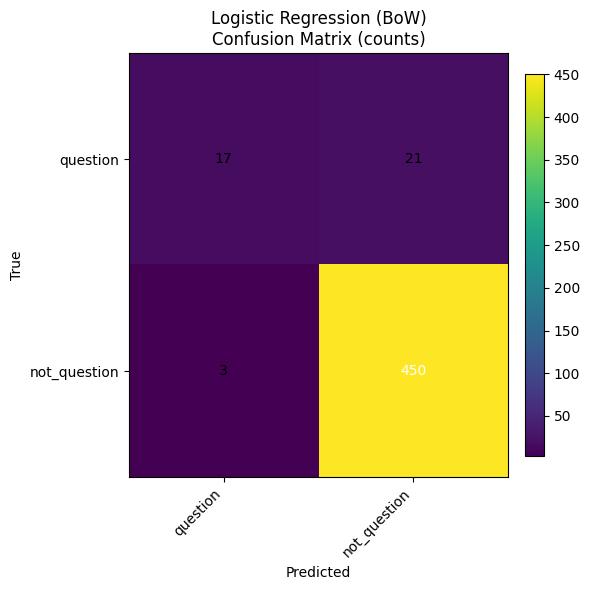

In [314]:
bow_vec = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
X_train_bow = bow_vec.fit_transform(sent_train)
X_test_bow  = bow_vec.transform(sent_test)

clf_bow = LogisticRegression(max_iter=500)
clf_bow.fit(X_train_bow, y_train)
y_pred_lr = clf_bow.predict(X_test_bow)

print(classification_report(y_test, y_pred_lr))

acc_bow = clf_bow.score(X_test_bow, y_test)
print("BoW accuracy:", acc_bow)
cm = plot_confusion_matrix(
    y_test, y_pred_lr,
    class_names=["question", "not_question"],
    title_prefix="Logistic Regression (BoW)"
)


### OHE

              precision    recall  f1-score   support

not_question       0.95      1.00      0.97       453
    question       0.94      0.39      0.56        38

    accuracy                           0.95       491
   macro avg       0.94      0.70      0.76       491
weighted avg       0.95      0.95      0.94       491

OHE accuracy: 0.9511201629327902
Logistic Regression (OHE) — classification report
              precision    recall  f1-score   support

    question      0.952     0.998     0.974       453
not_question      0.938     0.395     0.556        38

    accuracy                          0.951       491
   macro avg      0.945     0.696     0.765       491
weighted avg      0.950     0.951     0.942       491



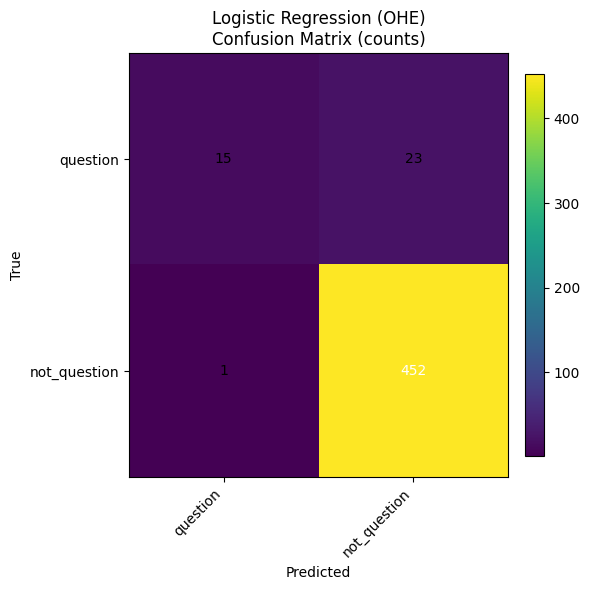

In [315]:
ohe_vec = CountVectorizer(binary=True, token_pattern=r"(?u)\b\w+\b")
X_train_ohe = ohe_vec.fit_transform(sent_train)
X_test_ohe  = ohe_vec.transform(sent_test)

clf_ohe = LogisticRegression(max_iter=500)
clf_ohe.fit(X_train_ohe, y_train)

y_pred_ohe = clf_ohe.predict(X_test_ohe)

print(classification_report(y_test, y_pred_ohe))

acc_ohe = clf_ohe.score(X_test_ohe, y_test)
print("OHE accuracy:", acc_ohe)
cm = plot_confusion_matrix(
    y_test, y_pred_ohe,
    class_names=["question", "not_question"],
    title_prefix="Logistic Regression (OHE)"
)


              precision    recall  f1-score   support

not_question       0.93      1.00      0.96       453
    question       1.00      0.13      0.23        38

    accuracy                           0.93       491
   macro avg       0.97      0.57      0.60       491
weighted avg       0.94      0.93      0.91       491

TF-IDF accuracy: 0.9327902240325866
Logistic Regression (TF-IDF) — classification report
              precision    recall  f1-score   support

    question      0.932     1.000     0.965       453
not_question      1.000     0.132     0.233        38

    accuracy                          0.933       491
   macro avg      0.966     0.566     0.599       491
weighted avg      0.937     0.933     0.908       491



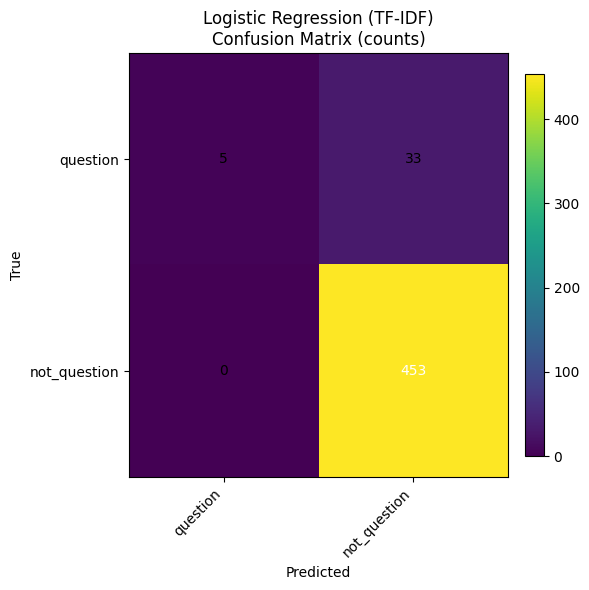

In [316]:
tfidf_vec = TfidfVectorizer(
    token_pattern=r"(?u)\b\w[\w']+\b",
    sublinear_tf=True,
    use_idf=True,
)

X_train_tfidf = tfidf_vec.fit_transform(sent_train)
X_test_tfidf  = tfidf_vec.transform(sent_test)

clf_tfidf = LogisticRegression(max_iter=500)
clf_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_tfidf))

acc_tfidf = clf_tfidf.score(X_test_tfidf, y_test)
print("TF-IDF accuracy:", acc_tfidf)

cm = plot_confusion_matrix(
    y_test,
    y_pred_tfidf,
    class_names=["question", "not_question"],
    title_prefix="Logistic Regression (TF-IDF)"
)


Entre las representaciones que probamos, la que considero que dio los mejores resultados fue la de **BoW**. Además, elegí el clasificador de regresión logística porque en promedio fue el que mejores resultados me dio en las tareas anteriores. Igual que en esas tareas de los mejores resultados  vuelve a ser **BoW + LR**, y eso no cambia en este caso. Y como era de esperar, la mayoría de las predicciones se iban a la clase `not_question` seguramente por el sesgo de que hay muchos más ejemplos de estos, aunque hayamos tratado de usar clases balanceadas en nuestras representaciones.

## 25. Visualizar en un grafo de coocurrencia los puntos donde cambia los temas a lo largo del texto.


Para construir el grafo de coocurrencias utilizamos dos librerías clave: **itertools** y **networkx**. `itertools.combinations` nos permite generar de forma compacta todos los pares posibles de palabras que aparecen juntas en una misma oración, lo cual sería engorroso de implementar manualmente. Por su parte, `networkx` proporciona una estructura de grafo flexible donde podemos añadir nodos, crear aristas y asignar pesos que representen la frecuencia de coocurrencia entre términos. Además, incluye algoritmos de visualización como `spring_layout`, que calcula posiciones naturales para los nodos según sus relaciones, facilitando interpretar dónde se agrupan conceptos relacionados y cómo evolucionan los temas a lo largo del texto.

Con ese vocabulario reducido de `cleaner_corpus`, creamos un grafo donde cada palabra es un nodo. Para cada oración extraemos las palabras relevantes y generamos todos los pares posibles de coocurrencia, si dos palabras aparecen en la misma oración, se crea o se incrementa una arista entre ellas. El peso de cada arista representa cuántas veces esas dos palabras aparecen juntas en el texto, lo cual captura asociaciones temáticas. Finalmente, utilizamos un diseño por fuerzas (`spring_layout`) que coloca más cerca los nodos con conexiones fuertes. El resultado es una visualización donde los grupos de palabras fuertemente conectadas permiten identificar núcleos temáticos y observar cómo se agrupan a lo largo del texto, mostrando de forma intuitiva los puntos en los que cambian o evolucionan los temas.



In [317]:
import itertools
import networkx as nx

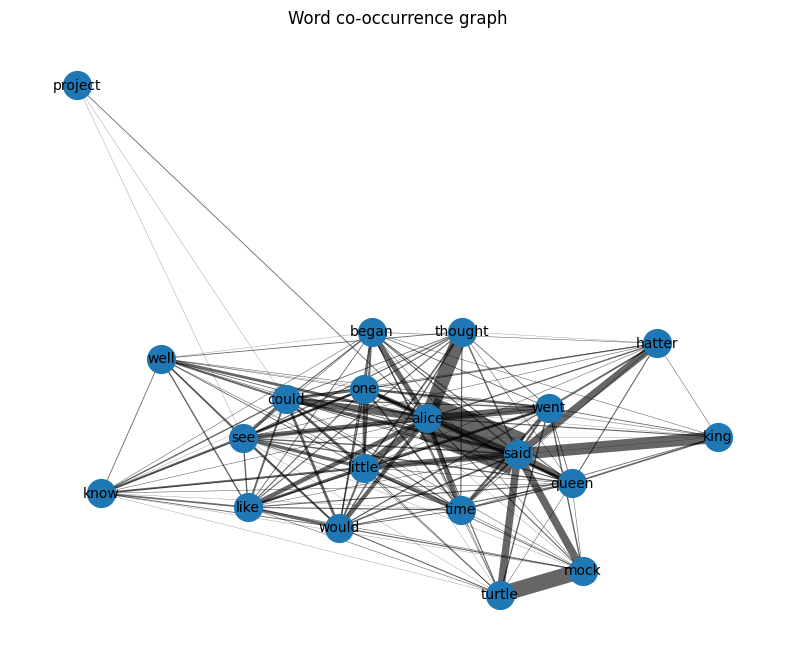

In [318]:
tokenized_clean = [line.split() for line in cleaner_corpus]

# Count word frequencies to keep only the most important words
word_freq = Counter(w for sent in tokenized_clean for w in sent)

# Keep only the top K most frequent words to keep the graph readable
K = 20
vocab = [w for w, _ in word_freq.most_common(K)]

G = nx.Graph()
G.add_nodes_from(vocab)

for sent in tokenized_clean:
    # Keep only relevant words from this sentence
    words = [w for w in set(sent) if w in vocab]
    # Add co-occurrence edges for all pairs in the sentence
    for w1, w2 in itertools.combinations(words, 2):
        if G.has_edge(w1, w2):
            G[w1][w2]['weight'] += 1
        else:
            G.add_edge(w1, w2, weight=1)

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, k=0.3, weight='weight', seed=42)

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

nx.draw_networkx_nodes(G, pos, node_size=400)
nx.draw_networkx_edges(G, pos, edgelist=edges,
                       width=[w * 0.2 for w in weights],
                       alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Word co-occurrence graph")
plt.axis('off')
plt.show()


Podemos ver por el gráfo que más o menos tenemos una representación correcta de lo que trata el libro con algunas palabras clave que estan fuertemente conectadas. En este caso los que más llaman la antención son `Alice`, `Queen`, `Hatter`, `King` que si no estoy mal, son de los personajes más iconicos e importantes del libro. Y pues tiene sentido que estén fuertemente conectados.


## 26. Aplicar las metricas de centralidad vistas en clase para determinar topicos relevantes sobre el grafo del punto previo.
### - Degree
### - Closeness
### - Betweenness


Usamos `nx.degree_centrality`, `nx.closeness_centrality` y `nx.betweenness_centrality` aprovechando que ya tenemos NetworkX, pues este ya tiene funciones que implementan estas métricas de forma optimizada y directamente sobre la estructura del grafo que generamos. Esto evita tener que calcular manualmente conexiones, distancias o rutas intermedias, operaciones que serían mucho más costosas y propensas a errores si se intentaran programar desde cero.


In [319]:
# Degree centrality
degree_centrality = nx.degree_centrality(G)

# Closeness centrality
closeness_centrality = nx.closeness_centrality(G, distance=None)

# Betweenness centrality
betweenness_centrality = nx.betweenness_centrality(
    G,
    normalized=True,
    weight='weight'
)


def top_k_from_dict(d, k=10):
    """
    Return the top-k items from a centrality dictionary,
    sorted from highest to lowest value.
    """
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:k]


print(f"\nTop {N} words by DEGREE centrality:")
for word, score in top_k_from_dict(degree_centrality, N):
    print(f"{word}: {score:.4f}")

print(f"\nTop {N} words by CLOSENESS centrality:")
for word, score in top_k_from_dict(closeness_centrality, N):
    print(f"{word}: {score:.4f}")

print(f"\nTop {N} words by BETWEENNESS centrality:")
for word, score in top_k_from_dict(betweenness_centrality, N):
    print(f"{word}: {score:.4f}")



Top 6 words by DEGREE centrality:
alice: 1.0000
could: 1.0000
see: 1.0000
said: 0.9474
little: 0.9474
one: 0.9474

Top 6 words by CLOSENESS centrality:
alice: 1.0000
could: 1.0000
see: 1.0000
said: 0.9500
little: 0.9500
one: 0.9500

Top 6 words by BETWEENNESS centrality:
know: 0.2259
king: 0.1469
see: 0.1221
hatter: 0.0950
turtle: 0.0871
mock: 0.0871


## 27 Proponer alguna tecnica de machine learning para agrupar texto (k-means, hearchical clustering, etc). hablando del proposito de esto para entender un corpus de datos.

Para agrupar el texto propusimos usar **K-Means** sobre la representación **TF-IDF** que ya habíamos construido. En lugar de inventar una nueva forma de representar el corpus, reutilizamos `tfidf_vec` y simplemente transformamos cada oración de `raw_corpus` en un vector numérico (`X_tfidf`), lo que nos permite trabajar con una matriz donde oraciones parecidas quedan cerca en el espacio. Elegimos K-Means porque es un método sencillo pero funcional el cual podemos sacar de  `sklearn` y encaja bien cuando queremos descubrir grupos de oraciones con patrones de vocabulario similar sin supervisión. Con los centroides de cada clúster (`kmeans.cluster_centers_`) recuperamos las palabras con mayor peso TF-IDF por grupo, lo que da una interpretación sobre el tema de cada clúster. Finalmente al graficar el id de clúster a lo largo del índice de oraciones, podemos ver cómo van cambiando estos grupos a lo largo del libro, es decir se cambian los temas del corpus sin necesidad de etiquetar manualmente los temas. Aunque es un poco confunso de ver la gráfica, nos apoyamos de los centroides impresos para reconcoer que tipo de contenido tiene cada cluster, y con la gráfica podemos vel el cambio con el tiempo apoyandonos del los colores.


In [320]:
from sklearn.cluster import KMeans


Cluster 0 — top 6 words:
['it' 'that' 'alice' 'to' 'not' 'no']

Cluster 1 — top 6 words:
['said' 'alice' 'the' 'thought' 'king' 'hatter']

Cluster 2 — top 6 words:
['the' 'and' 'in' 'said' 'on' 'his']

Cluster 3 — top 6 words:
['you' 'know' 'are' 'to' 'it' 'do']

Cluster 4 — top 6 words:
['of' 'what' 'is' 'the' 'gutenberg' 'project']

Cluster 5 — top 6 words:
['she' 'to' 'and' 'herself' 'her' 'was']


Text(0, 0.5, 'Cluster id')

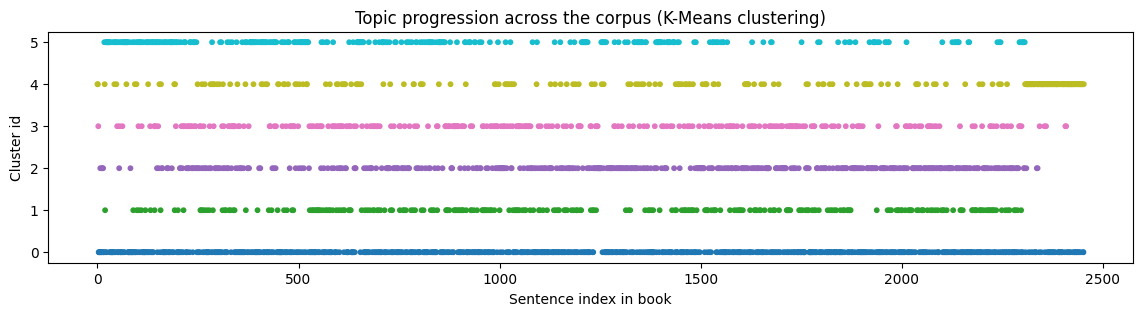

In [321]:
X_tfidf = tfidf_vec.transform(raw_corpus)
k = N

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_tfidf)

clusters = kmeans.labels_

feature_names = np.array(tfidf_vec.get_feature_names_out())
centroids = kmeans.cluster_centers_


for i in range(k):
    print(f"\nCluster {i} — top {N} words:")
    idx = centroids[i].argsort()[::-1][:N]
    print(feature_names[idx])


plt.figure(figsize=(14, 3))
plt.scatter(range(len(clusters)), clusters, c=clusters, cmap="tab10", s=10)
plt.title("Topic progression across the corpus (K-Means clustering)")
plt.xlabel("Sentence index in book")
plt.ylabel("Cluster id")

Lo que podemos ver de la gráfica es que el libro no progresa en bloques temáticos claramente separados, si no que los temas se mezclan y reaparecen en diferentes momentos. No puedo confirmar que esto sea así pues no he leído el libro, por lo que tendré que confiar en nuestra representación y creer que esto es así, o al menos que se parece a la realidad.


## Conclusión 

Después de haber terminado con todos los puntos y hacer un análisis, me permitió entender que trabajar con un corpus real implica mucho más que “cargar un libro y procesarlo”. Desde el principio me quedó claro que incluso textos publicados pueden contener errores o inconsistencias que afectan directamente cualquier análisis automático. Durante el preprocesamiento me di cuenta que el archivo tenía al menos una comilla faltante, lo que rompía la estructura de las citas y me obligó a construir un segmentador más cuidadoso, aparte de que le tuve que agregar esa comilla para solucionar este problema. También surgieron combinaciones poco comunes de signos de puntuación interrogaciones dentro de comillas, exclamaciones mezcladas con puntos, e incluso preguntas mal formadas como *"what are you doing, I asked?"* que no tiene ningún sentido en lo absoluto a la estructura de una pregunta real. Esto fue lo que hizo que no puediera confiar ciegamente en el material original, el proceso dejó claro que la limpieza del corpus es una etapa crítica para evitar análisis distorsionados o interpretaciones incorrectas que puede tomar un largo timepo para perfeccionar, pero que es sumamente necesario para que las cosas salgan como se esperan y no haya errores que pueden retrasarte más adelante.

Al pasar a las distintas representaciones las pruebas que se hiceron también me confirmaron que aunque existen métodos complejos y modelos avanzados, muchas veces las técnicas simples como Bag of Words o TF-IDF son más que suficientes para obtener resultados útiles. Son rápidas, fáciles de ajustar, y en la mayoría de los ejercicios realizados nos dan un desempeño comparable a los métodos más elaborados, siendo muchas veces mejores. Nuevamente confirmando mi idea de que antes de saltar a modelos sofisticados, es mejor probar primero con representaciones básicas que suelen resolver bien la mayoría de tareas. 